# Generate Comparison Figures — Classic Image Denoising Benchmark

Notebook này sinh ảnh so sánh theo layout cố định **2 hàng × 3 cột** giống hình mẫu:

```text
Original | Noisy | Gaussian
NLM      | BM3D  | K-SVD
```

Notebook **không chạy lại toàn bộ benchmark**. Nó chỉ:
1. đọc CSV raw đã sinh từ `benchmark_v2.py`,
2. lấy đúng `seed` và PSNR trong CSV,
3. tái tạo ảnh noisy,
4. chạy lại các method cho một vài ảnh bạn chọn để visualize,
5. lưu ảnh comparison vào `results/comparisons_from_notebook/...`.

> Lưu ý: CSV chỉ lưu metric, không lưu ảnh denoised, nên để vẽ hình comparison thì vẫn phải chạy lại denoise cho những ảnh được chọn.


In [9]:
# Cell 1 — Imports and path setup

from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage import io, color, img_as_ubyte

# Notebook expected path:
# classic_image_denoising_benchmark/notebooks/this_notebook.ipynb
#
# If your notebook is placed somewhere else, manually set ROOT below.
try:
    ROOT = Path.cwd()
    if ROOT.name == "notebooks":
        ROOT = ROOT.parent
except Exception:
    ROOT = Path("..").resolve()

SRC = ROOT / "src"
sys.path.insert(0, str(SRC))

print("Project root:", ROOT)
print("Source dir  :", SRC)


Project root: w:\Denoise Project\classic_image_denoising_benchmark
Source dir  : w:\Denoise Project\classic_image_denoising_benchmark\src


In [10]:
# Cell 2 — Import project modules

from noise import add_gaussian_noise
from filters import gaussian_filter, median_filter
from metrics import psnr, ssim

# Optional methods
try:
    from nlm import nlm_denoise_fast
    HAS_NLM = True
    print("Loaded NLM")
except Exception as e:
    HAS_NLM = False
    print("NLM not available:", e)

try:
    from bm3d_wrapper import bm3d_denoise
    HAS_BM3D = True
    print("Loaded BM3D")
except Exception as e:
    HAS_BM3D = False
    print("BM3D not available:", e)

try:
    from ksvd_denoising import ksvd_denoise
    HAS_KSVD = True
    print("Loaded K-SVD")
except Exception as e:
    HAS_KSVD = False
    print("K-SVD not available:", e)


Loaded NLM
Loaded BM3D
Loaded K-SVD


In [ ]:
# Cell 3 — Configuration

DATASET = "set12"       # "set12" or "bsd68"
SIGMA = 25              # 15, 25, or 50
CSV_PATH = ROOT / "results" / f"benchmark_v2_{DATASET}_raw.csv"

# Choose images by file stem.
# For Set12, examples are usually: "01", "02", ..., "12"
# Set to None to use the first LIMIT images.
SELECTED_IMAGES = None
LIMIT = 3

# K-SVD can be slow. Set True if you want faster figure generation.
SKIP_KSVD = False

# Layout title exactly like your sample.
FIGURE_TITLE = f"All Methods Comparison (σ={SIGMA})"

OUTPUT_DIR = ROOT / "results" / "comparisons_from_notebook" / f"{DATASET}_sigma{SIGMA}"

print("Dataset   :", DATASET)
print("Sigma     :", SIGMA)
print("CSV path  :", CSV_PATH)
print("Output dir:", OUTPUT_DIR)


Dataset   : set12
Sigma     : 25
CSV path  : w:\Denoise Project\classic_image_denoising_benchmark\results\benchmark_v2_set12_raw.csv
Output dir: w:\Denoise Project\classic_image_denoising_benchmark\results\comparisons_from_notebook\set12_sigma25


In [12]:
# Cell 4 — Helper functions

def read_grayscale_uint8(path: Path) -> np.ndarray:
    """Read image as grayscale uint8 in range [0, 255]."""
    img = io.imread(path)

    if img.ndim == 3:
        img = color.rgb2gray(img)
        img = img_as_ubyte(img)
    else:
        if img.dtype != np.uint8:
            img = img_as_ubyte(img)

    return img.astype(np.uint8)


def get_dataset_folder(dataset: str) -> Path:
    dataset = dataset.lower()

    if dataset == "set12":
        return ROOT / "data" / "Set12"
    if dataset == "bsd68":
        return ROOT / "data" / "BSD68"

    raise ValueError("DATASET must be 'set12' or 'bsd68'")


def list_dataset_images(dataset: str):
    folder = get_dataset_folder(dataset)

    files = sorted(
        list(folder.glob("*.png"))
        + list(folder.glob("*.jpg"))
        + list(folder.glob("*.jpeg"))
        + list(folder.glob("*.bmp"))
    )

    if len(files) == 0:
        raise RuntimeError(f"No images found in {folder}")

    return files


def get_metric_from_csv(df: pd.DataFrame, image_name: str, sigma: int, method: str, metric: str):
    row = df[
        (df["image"].astype(str) == str(image_name))
        & (df["sigma"].astype(int) == int(sigma))
        & (df["method"].astype(str) == str(method))
    ]

    if len(row) == 0:
        return None

    value = row.iloc[0][metric]
    if pd.isna(value):
        return None

    return float(value)


def get_seed_from_csv(df: pd.DataFrame, image_name: str, sigma: int) -> int:
    row = df[
        (df["image"].astype(str) == str(image_name))
        & (df["sigma"].astype(int) == int(sigma))
        & (df["method"].astype(str) == "Noisy")
    ]

    if len(row) == 0:
        raise RuntimeError(f"No seed found in CSV for image={image_name}, sigma={sigma}")

    return int(row.iloc[0]["seed"])


def safe_uint8(img: np.ndarray) -> np.ndarray:
    return np.clip(img, 0, 255).astype(np.uint8)


In [13]:
# Cell 5 — Load CSV and choose images

if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"CSV not found: {CSV_PATH}\n"
        "Run benchmark_v2.py first or update CSV_PATH in Cell 3."
    )

df = pd.read_csv(CSV_PATH, dtype={"image": str, "method": str})

df["image"] = df["image"].astype(str).str.strip()
df["method"] = df["method"].astype(str).str.strip()
df["sigma"] = df["sigma"].astype(int)

# Fix tên ảnh Set12: 1 -> 01, 2 -> 02, ...
if DATASET.lower() == "set12":
    df["image"] = df["image"].apply(lambda x: x.zfill(2) if x.isdigit() else x)

print(df[["image", "sigma", "method", "seed"]].head())
print("Images in CSV:", sorted(df["image"].unique())[:20])
print("Sigmas:", sorted(df["sigma"].unique()))
print("Methods:", sorted(df["method"].unique()))
print("CSV loaded:", CSV_PATH)
display(df.head())

image_files = list_dataset_images(DATASET)

if SELECTED_IMAGES is not None:
    wanted = set(str(x) for x in SELECTED_IMAGES)
    image_files = [p for p in image_files if p.stem in wanted]
else:
    image_files = image_files[:LIMIT]

print("Images selected:")
for p in image_files:
    print("-", p.name)


  image  sigma    method   seed
0    01     15     Noisy  15904
1    01     15  Gaussian  15904
2    01     15    Median  15904
3    01     15       NLM  15904
4    01     15      BM3D  15904
Images in CSV: ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12']
Sigmas: [np.int64(15), np.int64(25), np.int64(50)]
Methods: ['BM3D', 'Gaussian', 'Median', 'NLM', 'Noisy']
CSV loaded: w:\Denoise Project\classic_image_denoising_benchmark\results\benchmark_v2_set12_raw.csv


,dataset,image,sigma,method,psnr,ssim,runtime_ms,seed
0,set12,01,15,Noisy,24.882344,0.509389,0.0000,15904
1,set12,01,15,Gaussian,24.181789,0.748949,253.9839,15904
2,set12,01,15,Median,25.908543,0.681779,617.3248,15904
3,set12,01,15,NLM,29.885658,0.840849,199.3645,15904
4,set12,01,15,BM3D,31.817403,0.899212,836.9154,15904


Images selected:
- 01.png
- 02.png
- 03.png


In [14]:
# Cell 6 — Denoising functions for fixed 2x3 layout

def run_gaussian(noisy: np.ndarray, sigma: int) -> np.ndarray:
    return safe_uint8(gaussian_filter(noisy, kernel_size=5, sigma=1.5))


def run_nlm(noisy: np.ndarray, sigma: int) -> np.ndarray:
    if not HAS_NLM:
        raise RuntimeError("NLM module is not available.")
    return safe_uint8(nlm_denoise_fast(noisy, patch_size=5, search_size=21, h=sigma))


def run_bm3d(noisy: np.ndarray, sigma: int) -> np.ndarray:
    if not HAS_BM3D:
        raise RuntimeError("BM3D module is not available.")
    return safe_uint8(bm3d_denoise(noisy, sigma_psd=sigma))


def run_ksvd(noisy: np.ndarray, sigma: int) -> np.ndarray:
    if SKIP_KSVD:
        raise RuntimeError("K-SVD skipped by configuration.")
    if not HAS_KSVD:
        raise RuntimeError("K-SVD module is not available.")

    result, _, _ = ksvd_denoise(
        noisy,
        dict_size=128,
        patch_size=8,
        iterations=5,
        sparsity=3,
    )
    return safe_uint8(result)


METHOD_RUNNERS = {
    "Gaussian": run_gaussian,
    "NLM": run_nlm,
    "BM3D": run_bm3d,
    "K-SVD": run_ksvd,
}


In [15]:
# Cell 7 — Create one comparison figure, exactly 2 rows x 3 columns

def make_panel_title(name: str, p=None, sigma: int = None) -> str:
    if name == "Original":
        return "Original"

    if name == "Noisy":
        if p is None:
            return f"Noisy (σ={sigma})"
        return f"Noisy (σ={sigma})\nPSNR={p:.2f} dB"

    if p is None:
        return name

    return f"{name}\nPSNR={p:.2f} dB"


def create_comparison_figure(image_path: Path, show: bool = True, save: bool = True):
    image_name = image_path.stem

    clean = read_grayscale_uint8(image_path)

    seed = get_seed_from_csv(df, image_name=image_name, sigma=SIGMA)
    noisy = add_gaussian_noise(clean, sigma=SIGMA, seed=seed)

    panels = []

    # Fixed order exactly like your sample:
    # Original | Noisy | Gaussian
    # NLM      | BM3D  | K-SVD
    panels.append(("Original", clean, None))

    noisy_psnr = get_metric_from_csv(df, image_name, SIGMA, "Noisy", "psnr")
    panels.append(("Noisy", noisy, noisy_psnr))

    for method_name in ["Gaussian", "NLM", "BM3D", "K-SVD"]:
        runner = METHOD_RUNNERS[method_name]

        print(f"Running {image_name} | σ={SIGMA} | {method_name}")

        try:
            denoised = runner(noisy, SIGMA)

            # Prefer PSNR from CSV so the title matches benchmark_v2.py output.
            method_psnr = get_metric_from_csv(df, image_name, SIGMA, method_name, "psnr")

            # If CSV does not have it, compute it here.
            if method_psnr is None:
                method_psnr = psnr(clean, denoised)

            panels.append((method_name, denoised, method_psnr))

        except Exception as e:
            # Keep fixed 2x3 layout even if a method fails.
            blank = np.ones_like(clean, dtype=np.uint8) * 255
            panels.append((f"{method_name}\nUnavailable", blank, None))
            print(f"WARNING: {method_name} failed on {image_name}: {e}")

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(FIGURE_TITLE, fontsize=16)

    for ax, (title, img, p) in zip(axes.flat, panels):
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.axis("off")

        # Set title to match the sample style.
        if title == "Noisy":
            ax.set_title(make_panel_title("Noisy", p, SIGMA), fontsize=12)
        elif "Unavailable" in title:
            ax.set_title(title, fontsize=12)
        else:
            ax.set_title(make_panel_title(title, p, SIGMA), fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    output_path = OUTPUT_DIR / f"{image_name}_comparison_sigma{SIGMA}.png"

    if save:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=200, bbox_inches="tight")
        print("Saved:", output_path)

    if show:
        plt.show()
    else:
        plt.close(fig)

    return output_path


Running 01 | σ=25 | Gaussian
Running 01 | σ=25 | NLM
Running 01 | σ=25 | BM3D
Running 01 | σ=25 | K-SVD
Step 1: Normalization
Step 2: Extracting patches...
  Extracted 62001 patches of size 8×8
  Total patch dimension: 64
Step 3: Learning dictionary with K-SVD...
K-SVD: 62001 patches of dim 64, dict_size=128
       sparsity=3, iterations=5

Iteration 1/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.267357

Iteration 2/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.208764

Iteration 3/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.202660

Iteration 4/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.196822

Iteration 5/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.193940

✓ K-SVD completed
Step 4: Recons

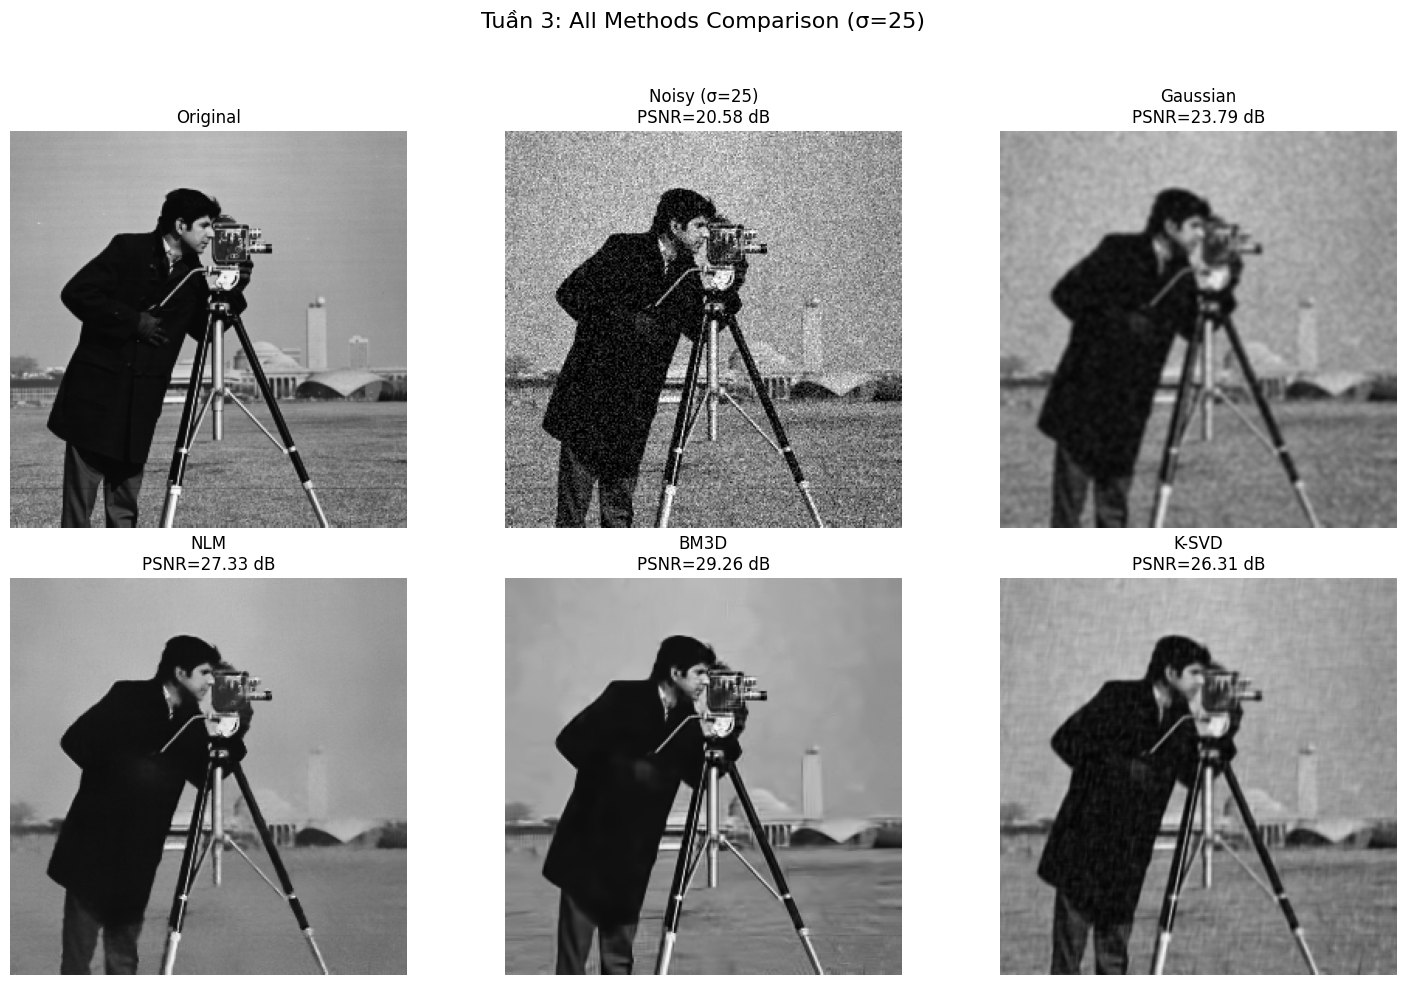

WindowsPath('w:/Denoise Project/classic_image_denoising_benchmark/results/comparisons_from_notebook/set12_sigma25/01_comparison_sigma25.png')

In [16]:
# Cell 8 — Generate preview for the first selected image

preview_path = create_comparison_figure(image_files[0], show=True, save=True)
preview_path


In [17]:
# Cell 9 — Batch generate comparison figures for all selected images

saved_paths = []

for image_path in image_files:
    print("=" * 80)
    print("Generating:", image_path.name)
    out = create_comparison_figure(image_path, show=False, save=True)
    saved_paths.append(out)

print("\nDone. Saved files:")
for p in saved_paths:
    print(p)


Generating: 01.png
Running 01 | σ=25 | Gaussian
Running 01 | σ=25 | NLM
Running 01 | σ=25 | BM3D
Running 01 | σ=25 | K-SVD
Step 1: Normalization
Step 2: Extracting patches...
  Extracted 62001 patches of size 8×8
  Total patch dimension: 64
Step 3: Learning dictionary with K-SVD...
K-SVD: 62001 patches of dim 64, dict_size=128
       sparsity=3, iterations=5

Iteration 1/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.260831

Iteration 2/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.209534

Iteration 3/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.198841

Iteration 4/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.195511

Iteration 5/5
  Sparse coding (OMP)...
  OMP: 62001/62001 done
  Dictionary update (SVD)...
       Relative error: 0.193403

✓ K-SVD compl

## Gợi ý sử dụng

### Sinh ảnh cho 3 ảnh đầu Set12

Ở Cell 3:

```python
DATASET = "set12"
SIGMA = 25
SELECTED_IMAGES = None
LIMIT = 3
```

### Chọn ảnh cụ thể

Ở Cell 3:

```python
SELECTED_IMAGES = ["01", "04", "07"]
LIMIT = None
```

### Bỏ K-SVD cho nhanh

Ở Cell 3:

```python
SKIP_KSVD = True
```

### Output

Ảnh sẽ được lưu tại:

```text
results/comparisons_from_notebook/<dataset>_sigma<sigma>/
```
